**Table of contents**<a id='toc0_'></a>

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import time
from collections import namedtuple

import numpy as np
import numba as nb
import matplotlib.pyplot as plt

from consav.grids import equilogspace
from consav.markov import log_rouwenhorst
from consav.linear_interp import interp_1d, interp_1d_vec
from consav.golden_section_search import optimizer

# The endogenous grid method

This notebook solves the same infinite-horizon household problem as the previous one, but with the endogenous
grid method (EGM) of Carroll instead of value function iteration.

The function we end up with, `solve_hh_backwards`, is the one we use for the rest of the course. It comes back
almost line for line in `04-Stationary-Equilibrium/0_HANC/household_problem.py`.

## Why not VFI?

The standard method to solve the household problem is VFI: guess a value function $v(z_t,a_{t-1})$ and iterate on
the right-hand side of the Bellman equation,
$v^{n+1}(z_t,a_{t-1}) = \max_{c_t}\{u(c_t)+\beta\mathbb{E}_t[v^{n}(z_{t+1},a_t)]\}$, until $v^{n+1} \approx v^{n}$.

The issue with this method is that for each point $(z_t,a_{t-1})$ on our grids we need to run an optimization
algorithm, like the golden section search of the previous notebook, and that is costly. It is also not very
accurate, as we saw with the MPC.

The endogenous grid method proposes to iterate on the Euler-equation instead.

## The model

$$
\begin{aligned}
v(z_t,a_{t-1}) &= \max_{c_t} \frac{c_t^{1-\sigma}}{1-\sigma} + \beta \mathbb{E}_t\left[v(z_{t+1},a_t)\right] \\
&\text{s.t.} \\
a_t &= (1+r)a_{t-1} + wz_t - c_t \geq 0 \\
\log z_{t+1} &= \rho_z \log z_t + \psi_{t+1}, \qquad \psi_{t+1}\sim\mathcal{N}(0,\sigma_\psi^2), \qquad \mathbb{E}[z_t]=1
\end{aligned}
$$

Exactly the model of the previous notebook. Only the solution method changes.

One implementation detail: we want the solver to be `numba`-compiled, and `numba` cannot take an ordinary Python
class. We therefore hold the parameters in a `namedtuple`, whose attributes it does understand. In lecture 04 the
same job is done by `EconModelClass` together with `jit`.

In [2]:
Parameters = namedtuple('Parameters',
    'beta sigma r w rho_z sigma_psi Nz Na a_min a_max a_grid z_grid z_trans z_ergodic')

def setup():
    """ baseline parameters """

    # preferences
    beta = 0.96
    sigma = 2.0

    # prices
    r = 0.02
    w = 1.0

    # income
    rho_z = 0.95
    sigma_psi = 0.10
    Nz = 7
    z_grid,z_trans,z_ergodic,_,_ = log_rouwenhorst(rho_z,sigma_psi,Nz)

    # grids
    Na = 300
    a_min = 0.0
    a_max = 100.0
    a_grid = equilogspace(a_min,a_max,Na)

    return Parameters(beta,sigma,r,w,rho_z,sigma_psi,Nz,Na,a_min,a_max,a_grid,z_grid,z_trans,z_ergodic)

par = setup()

In [3]:
print('z_grid    =',np.round(par.z_grid,4))
print('z_ergodic =',np.round(par.z_ergodic,4))
print('mean of z =',np.sum(par.z_grid*par.z_ergodic))

z_grid    = [0.4336 0.5632 0.7315 0.9501 1.2341 1.6029 2.082 ]
z_ergodic = [0.0156 0.0938 0.2344 0.3125 0.2344 0.0937 0.0156]
mean of z = 0.9999999999999998


## The EGM algorithm, step by step

Our goal is to obtain the policy functions $a^{\ast}(z_t,a_{t-1})$ and $c^{\ast}(z_t,a_{t-1})$ for each point on the grids `a_grid`
and `z_grid`.

Recall that the first-order condition of the problem writes $u'(c_t)=\beta \underline{v}_a(z_t,a_t)$ where
$\underline{v}(z_t,a_t) = \mathbb{E}_t[v(z_{t+1},a_t)]$ is the beginning-of-period value function from the last notebook.
Our first step is thus to define an initial guess for $\underline{v}_a$.

In [4]:
c = par.r*par.a_grid[np.newaxis,:] + par.w*par.z_grid[:,np.newaxis] # implied guess of a(z,a_) = a_
v_a = (1+par.r)*c**(-par.sigma) # envelope condition, given our guess on the policy function
vbeg_a = par.z_trans@v_a # take the expectation with a matrix multiplication

Instead of fixing a grid over the state $a_{t-1}$, we now set a grid over the choice $a_t$. We can then use the first-order condition
to obtain $c_t$ as a function of $a_t$,

$$
c(z_t,a_t) = u'^{-1}\left[\beta \underline{v}_a(z_t,a_t)\right] = \left(\beta \underline{v}_a(z_t,a_t)\right)^{-1/\sigma}
$$

In [5]:
c_endo = (par.beta*vbeg_a)**(-1/par.sigma) # invert the FOC to get c(z,a)

print('c_endo.shape =',c_endo.shape)

c_endo.shape = (7, 300)


We also know that, from the budget constraint,

$$
a_t + c(z_t,a_t) = (1+r)a_{t-1} + wz_t
$$

Note that in this equation $a_t$ and $z_t$ are defined on their grids, and we now know $c(z_t,a_t)$. We can thus invert
it to obtain

$$
a_{t-1}(z_t,a_t) = \frac{a_t + c(z_t,a_t) - wz_t}{1+r}
$$

where $a_{t-1}(z_t,a_t)$ is the *endogenous grid* for assets, hence the name of the method.

We are reversing the problem: instead of finding the optimal $a_t$ given the state $(z_t,a_{t-1})$, we are asking
which $a_{t-1}$ today would make it optimal to choose $a_t$, given the Euler-equation.

Of course, we are eventually interested in $a^{\ast}(z_t,a_{t-1})$ on the *exogenous* grid. To get there we interpolate
the function $a_t(z_t,a_{t-1}^{\text{endo}})$ at the points `a_grid`. Note that `interp_1d_vec` writes its result into the
array we pass last, rather than returning it.

In [6]:
a = np.zeros((par.Nz,par.Na))

for i_z in range(par.Nz):

    # a. endogenous grid from the budget constraint
    a_endo = (c_endo[i_z] + par.a_grid - par.w*par.z_grid[i_z])/(1+par.r)

    # b. interpolate a(z,a_endo) at the points a_grid, which gives a(z,a_)
    interp_1d_vec(a_endo,par.a_grid,par.a_grid,a[i_z])

The last thing to note is that, because of the borrowing constraint, some of the $a^{\ast}(z_t,a_{t-1})$ implied by the
first-order condition are not feasible. We simply impose the constraint by setting them to zero.

In [7]:
a = np.fmax(a,0.0) # enforce the borrowing constraint

We can then compute $c^{\ast}(z_t,a_{t-1})$ as the residual of the budget constraint, use the envelope condition to
update our guess of the derivative of the value function,

$$
v_a(z_t,a_{t-1}) = (1+r)c^{\ast}(z_t,a_{t-1})^{-\sigma}
$$

and take the expectation with the transition matrix.

In [8]:
for i_z in range(par.Nz):
    c[i_z] = par.a_grid*(1+par.r) + par.w*par.z_grid[i_z] - a[i_z] # consumption from the budget constraint

v_a = (1+par.r)*c**(-par.sigma) # envelope condition
vbeg_a_new = par.z_trans@v_a # expectation step

## Putting it in a function

We then put all of this in one function and iterate until convergence.

Algorithm:
Guess a function $\underline{v}_a(z_t,a_t)$. Then
1. Back out the implied consumption, $c(z_t,a_t) = u'^{-1}\left[\beta\underline{v}_a(z_t,a_t)\right]$
2. Get an *endogenous grid* for assets from the budget constraint, $a_{t-1}(z_t,a_t)=\frac{a_t+c(z_t,a_t)-wz_t}{1+r}$
3. This gives $a^{\ast}(z_t,a_{t-1})$ on the endogenous grid. Put it back on the exogenous grid by interpolation
4. Impose the borrowing constraint by setting $a^{\ast}(z_t,a_{t-1})<0$ to zero
5. Back out consumption from the budget constraint, $c^{\ast}(z_t,a_{t-1})=(1+r)a_{t-1}+wz_t-a^{\ast}(z_t,a_{t-1})$
6. Update the guess with the envelope condition, $\underline{v}_a(z_t,a_t) = \mathbb{E}_t\left[(1+r)u'(c^{\ast}(z_{t+1},a_t))\right]$, one product with $\Pi_z$

Iterate until convergence.

Two things about the implementation. The loop over productivity states runs in parallel with `nb.prange`, since
the states do not talk to each other within a step. And the outputs `vbeg_a`, `a` and `c` are written *into*
arrays we pass in, rather than returned: allocating fresh arrays on every one of a few hundred iterations would
be wasteful, and this is the convention `GEModelTools` expects.

In [9]:
@nb.njit(parallel=True)
def solve_hh_backwards(par,z_trans,r,w,vbeg_a_plus,vbeg_a,a,c):
    """ solve backwards with vbeg_a from previous iteration (here vbeg_a_plus) """

    # a. solve step
    for i_z in nb.prange(par.Nz):

        # i. back out consumption from Va
        c_endo = (par.beta*vbeg_a_plus[i_z])**(-1/par.sigma)

        # ii. compute endogenous grid of assets
        a_endo = (c_endo + par.a_grid - w*par.z_grid[i_z])/(1+r)

        # iii. interpolation to fixed grid
        interp_1d_vec(a_endo,par.a_grid,par.a_grid,a[i_z])

        # iv. impose borrowing constraint
        a[i_z,:] = np.fmax(a[i_z,:],0.0) # enforce borrowing constraint

        # v. back out consumption
        c[i_z] = par.a_grid*(1+r) + w*par.z_grid[i_z] - a[i_z]

    # b. expectation step
    v_a = (1+r)*c**(-par.sigma) # envelope condition
    vbeg_a[:] = z_trans@v_a # expectation step

Then, for a given $r$ and $w$, we loop over this step until the `vbeg_a_plus` we feed into the function is
arbitrarily close to the `vbeg_a` that it writes out.

In [10]:
def solve_hh_ss(par,r,w,max_iter=10_000,tol=1e-10):
    """ solve the household problem in the infinite horizon """

    # a. allocate
    vbeg_a = np.zeros((par.Nz,par.Na))
    a = np.zeros((par.Nz,par.Na))
    c = np.zeros((par.Nz,par.Na))

    # b. initial guess: a(z,a_) = a_, so consumption is the annuity value
    c_guess = r*par.a_grid[np.newaxis,:] + w*par.z_grid[:,np.newaxis]
    vbeg_a_plus = par.z_trans@((1+r)*c_guess**(-par.sigma))

    errors = []

    # c. iterate
    for it in range(max_iter):

        solve_hh_backwards(par,par.z_trans,r,w,vbeg_a_plus,vbeg_a,a,c)

        error = np.max(np.abs(vbeg_a-vbeg_a_plus))
        errors.append(error)
        if error < tol: break

        vbeg_a_plus[:] = vbeg_a

    return c,a,vbeg_a,errors

In [11]:
t0 = time.time()
c,a,vbeg_a,errors = solve_hh_ss(par,par.r,par.w)

print(f'converged in {len(errors)} iterations and {time.time()-t0:.2f} seconds')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


converged in 280 iterations and 2.36 seconds


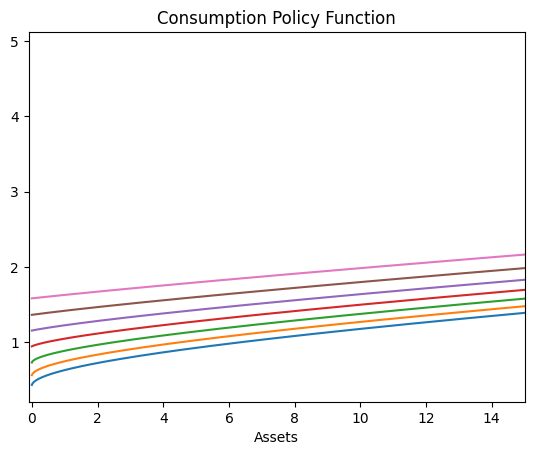

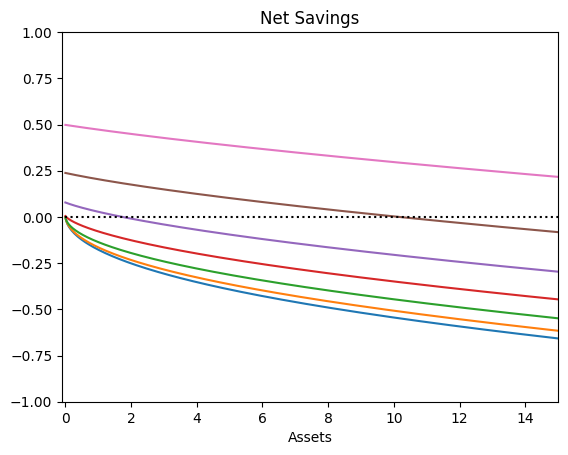

In [13]:
plt.plot(par.a_grid,c.T)
plt.xlim(-0.1,15)
plt.title('Consumption Policy Function')
plt.xlabel('Assets')
plt.savefig('figs/egm_c_func.pdf')
plt.show()

plt.plot(par.a_grid,(a-par.a_grid[np.newaxis,:]).T)
plt.plot(par.a_grid,np.zeros_like(par.a_grid),linestyle=':',color='black')
plt.xlim(-0.1,15)
plt.ylim(-1,1)
plt.title('Net Savings')
plt.xlabel('Assets')
plt.savefig('figs/egm_a_func.pdf')
plt.show()

As expected, the consumption function is a concave function of wealth, and net savings are a decreasing
function of wealth which crosses the zero line, implying buffer-stock behavior.

## EGM vs VFI

We now have two solutions of the same problem: VFI from the previous notebook and EGM here.
Let us compare them on speed and on the policy functions they produce.

Below is the VFI step of the previous notebook, only rewritten to take `par` as a namedtuple and prices as arguments, like `solve_hh_backwards`.
`value_of_choice` is unchanged.

In [14]:
@nb.njit
def value_of_choice(c,m,beta,sigma,a_grid,v_plus):
    """ negative of the value of consuming c out of cash-on-hand m """

    return -(c**(1-sigma)/(1-sigma) + beta*interp_1d(a_grid,v_plus,m-c))

@nb.njit(parallel=True)
def vfi_step(par,z_trans,r,w,v_plus,v,c,a):
    """ one backward step of value function iteration """

    # a. expectation step
    vbeg_plus = z_trans@v_plus

    # b. solve step
    for i_z in nb.prange(par.Nz):
        for i_a_lag in range(par.Na):

            # i. cash-on-hand and maximum consumption
            m = (1+r)*par.a_grid[i_a_lag] + w*par.z_grid[i_z]
            c_max = m - par.a_min

            # ii. optimize
            c[i_z,i_a_lag] = optimizer(value_of_choice,1e-8,c_max,
                args=(m,par.beta,par.sigma,par.a_grid,vbeg_plus[i_z]),tol=1e-10)

            # iii. save
            a[i_z,i_a_lag] = m - c[i_z,i_a_lag]
            v[i_z,i_a_lag] = -value_of_choice(c[i_z,i_a_lag],m,par.beta,par.sigma,par.a_grid,vbeg_plus[i_z])

def solve_vfi_ss(par,r,w,max_iter=10_000,tol=1e-8):
    """ solve the infinite-horizon problem with value function iteration """

    c = np.zeros((par.Nz,par.Na))
    a = np.zeros((par.Nz,par.Na))
    v = np.zeros((par.Nz,par.Na))

    # a. initial guess: consume the annuity value forever
    c_guess = r*par.a_grid[np.newaxis,:] + w*par.z_grid[:,np.newaxis]
    v_plus = c_guess**(1-par.sigma)/(1-par.sigma)/(1-par.beta)

    errors = []

    # b. iterate
    for it in range(max_iter):

        vfi_step(par,par.z_trans,r,w,v_plus,v,c,a)

        error = np.max(np.abs(v-v_plus))
        errors.append(error)
        if error < tol: break

        v_plus[:] = v

    return c,a,v,errors

In [15]:
c_vfi,a_vfi,v_vfi,errors_vfi = solve_vfi_ss(par,par.r,par.w)

print(f'VFI converged in {len(errors_vfi)} iterations, EGM in {len(errors)}')

VFI converged in 339 iterations, EGM in 280


### Speed

Compilation happens once, so what matters for the equilibrium solver of lecture 04, which calls the backward step thousands of times, is the cost of a step after that.
We time 100 steps of each method, starting from the converged solution so that nothing moves.

In [16]:
# a. VFI
v_plus = v_vfi.copy()

t0 = time.time()
for _ in range(100):
    vfi_step(par,par.z_trans,par.r,par.w,v_plus,v_vfi,c_vfi,a_vfi)
t_vfi = (time.time()-t0)/100

# b. EGM
vbeg_a_plus = vbeg_a.copy()

t0 = time.time()
for _ in range(100):
    solve_hh_backwards(par,par.z_trans,par.r,par.w,vbeg_a_plus,vbeg_a,a,c)
t_egm = (time.time()-t0)/100

print(f'VFI: {1000*t_vfi:7.3f} ms per step, {len(errors_vfi)} iterations, {t_vfi*len(errors_vfi):.3f} s to converge')
print(f'EGM: {1000*t_egm:7.3f} ms per step, {len(errors)} iterations, {t_egm*len(errors):.3f} s to converge')
print(f'EGM is {t_vfi/t_egm:.0f} times faster per step')

VFI:   1.103 ms per step, 339 iterations, 0.374 s to converge
EGM:   0.086 ms per step, 280 iterations, 0.024 s to converge
EGM is 13 times faster per step


A VFI step runs a golden section search at every one of the $\#_z \times \#_a$ grid points, and each search evaluates `value_of_choice`, with its interpolation, a few dozen times.
An EGM step is a handful of vectorized operations and one interpolation per productivity state, with no optimizer at all.
The number of iterations is similar, since both are contractions with the same modulus $\beta$, so the gap per step is the gap in total.

### Policy functions

EGM is faster, but do the two methods agree?
We plot the consumption function from both for the lowest, middle and highest productivity state, and the relative difference between them.

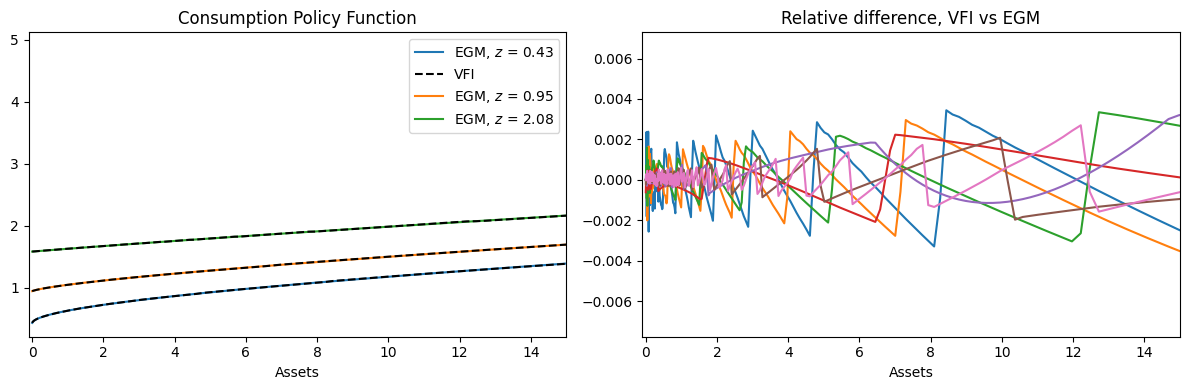

max relative difference in c: 7.08e-03
max relative difference in a: 1.16e-03


In [17]:
fig,ax = plt.subplots(1,2,figsize=(12,4))

for i_z in [0,par.Nz//2,par.Nz-1]:
    ax[0].plot(par.a_grid,c[i_z],label=f'EGM, $z$ = {par.z_grid[i_z]:.2f}')
    ax[0].plot(par.a_grid,c_vfi[i_z],linestyle='--',color='black',label='VFI' if i_z == 0 else None)
ax[0].set_xlim(-0.1,15)
ax[0].set_title('Consumption Policy Function')
ax[0].set_xlabel('Assets')
ax[0].legend()

ax[1].plot(par.a_grid,(c_vfi/c-1).T)
ax[1].set_xlim(-0.1,15)
ax[1].set_title('Relative difference, VFI vs EGM')
ax[1].set_xlabel('Assets')

fig.tight_layout()
fig.savefig('figs/egm_vs_vfi_c_func.pdf')
plt.show()

print(f'max relative difference in c: {np.max(np.abs(c_vfi/c-1)):.2e}')
print(f'max relative difference in a: {np.max(np.abs(a_vfi-a)/(1+par.a_grid[np.newaxis,:])):.2e}')

The two consumption functions are indistinguishable to the eye and differ by less than one percent.
The difference is VFI's error, not EGM's: EGM interpolates the *policy* function, VFI interpolates the *value* function, and the policy function is much closer to a straight line, so linear interpolation costs it far less.

The difference has a visible sawtooth shape.
The interpolated value function is piecewise linear with kinks at the grid points, so the optimizer tends to park $a_t$ on a grid point and stay there while $a_{t-1}$ moves, until the next grid point takes over.
Each tooth is one such grid point.
This is also why the MPC that came out ragged in the previous notebook is clean here.

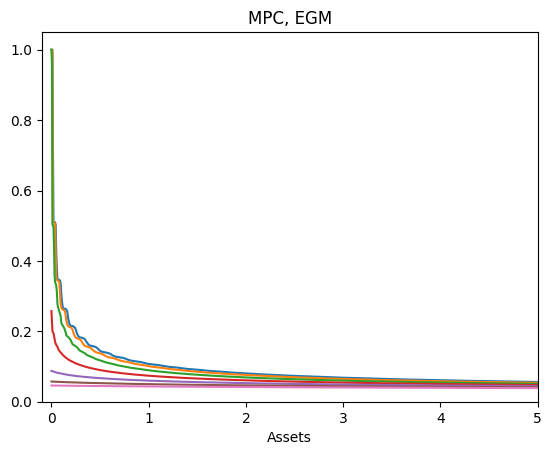

negative MPCs: 0 with EGM, 32 with VFI


In [18]:
MPC_egm = np.zeros((par.Nz,par.Na))
MPC_egm[:,:-1] = (c[:,1:]-c[:,:-1])/((1+par.r)*(par.a_grid[1:]-par.a_grid[:-1]))
MPC_egm[:,-1] = MPC_egm[:,-2]

plt.plot(par.a_grid,MPC_egm.T)
plt.xlim(-0.1,5)
plt.ylim(0,1.05)
plt.title('MPC, EGM')
plt.xlabel('Assets')
plt.savefig('figs/egm_MPC.pdf')
plt.show()

MPC_vfi = np.zeros((par.Nz,par.Na))
MPC_vfi[:,:-1] = (c_vfi[:,1:]-c_vfi[:,:-1])/((1+par.r)*(par.a_grid[1:]-par.a_grid[:-1]))
MPC_vfi[:,-1] = MPC_vfi[:,-2]

print(f'negative MPCs: {np.sum(MPC_egm < 0)} with EGM, {np.sum(MPC_vfi < 0)} with VFI')

## Exercise: permanent productivity types

So far households differ only through the Markov state $z_t$, which moves every period.
Suppose there are also *permanent* types: type $i$ has productivity $\xi_i$, fixed for life, so labor income is $w\xi_i z_t$.
Take three types, $\xi \in \{0.5, 1, 1.5\}$, with equal shares.

1. Write `solve_hh_backwards_fix`. Loop over types outside the loop over $z$, use income `w*xi_grid[i_fix]*par.z_grid[i_z]`, and index all arrays as `[i_fix,i_z]`. The expectation step is one matrix product per type.
2. `solve_hh_ss_fix` is given. Solve and check that it converges.
3. Plot the consumption function of the three types for the middle productivity state.
4. With CRRA utility and $\underline{a} = 0$ the problem is *homogeneous*: scaling all income by $\xi$ scales the policy functions,
$c^{\ast}(z,a_{-1};\xi) = \xi\, c^{\ast}(z,a_{-1}/\xi;1)$.
Check this numerically with `interp_1d_vec`. What does it imply for the distribution of wealth *relative to income* across types?

In [ ]:
xi_grid = np.array([0.5,1.0,1.5])

@nb.njit(parallel=True)
def solve_hh_backwards_fix(par,xi_grid,z_trans,r,w,vbeg_a_plus,vbeg_a,a,c):
    """ one EGM backward step with permanent productivity types """

    pass


In [20]:
def solve_hh_ss_fix(par,xi_grid,r,w,max_iter=10_000,tol=1e-10):
    """ solve the household problem with permanent types """

    Nfix = xi_grid.size

    # a. allocate
    vbeg_a = np.zeros((Nfix,par.Nz,par.Na))
    a = np.zeros((Nfix,par.Nz,par.Na))
    c = np.zeros((Nfix,par.Nz,par.Na))

    # b. initial guess: consume the annuity value
    c_guess = r*par.a_grid[np.newaxis,np.newaxis,:] + w*xi_grid[:,np.newaxis,np.newaxis]*par.z_grid[np.newaxis,:,np.newaxis]
    vbeg_a_plus = np.zeros_like(c_guess)
    for i_fix in range(Nfix):
        vbeg_a_plus[i_fix] = par.z_trans@((1+r)*c_guess[i_fix]**(-par.sigma))

    # c. iterate
    for it in range(max_iter):

        solve_hh_backwards_fix(par,xi_grid,par.z_trans,r,w,vbeg_a_plus,vbeg_a,a,c)

        if np.max(np.abs(vbeg_a-vbeg_a_plus)) < tol: break
        vbeg_a_plus[:] = vbeg_a

    return c,a,vbeg_a,it

In [21]:
# solve, plot the three consumption functions, check homogeneity


## Answers

In [22]:
@nb.njit(parallel=True)
def solve_hh_backwards_fix(par,xi_grid,z_trans,r,w,vbeg_a_plus,vbeg_a,a,c):
    """ one EGM backward step with permanent productivity types """

    for i_fix in range(xi_grid.size):

        # a. solve step
        for i_z in nb.prange(par.Nz):

            income = w*xi_grid[i_fix]*par.z_grid[i_z]

            # i. back out consumption from Va
            c_endo = (par.beta*vbeg_a_plus[i_fix,i_z])**(-1/par.sigma)

            # ii. compute endogenous grid of assets
            a_endo = (c_endo + par.a_grid - income)/(1+r)

            # iii. interpolation to fixed grid
            interp_1d_vec(a_endo,par.a_grid,par.a_grid,a[i_fix,i_z])

            # iv. impose borrowing constraint
            a[i_fix,i_z,:] = np.fmax(a[i_fix,i_z,:],0.0)

            # v. back out consumption
            c[i_fix,i_z] = par.a_grid*(1+r) + income - a[i_fix,i_z]

        # b. expectation step for this type
        v_a = (1+r)*c[i_fix]**(-par.sigma)
        vbeg_a[i_fix] = z_trans@v_a

converged in 315 iterations


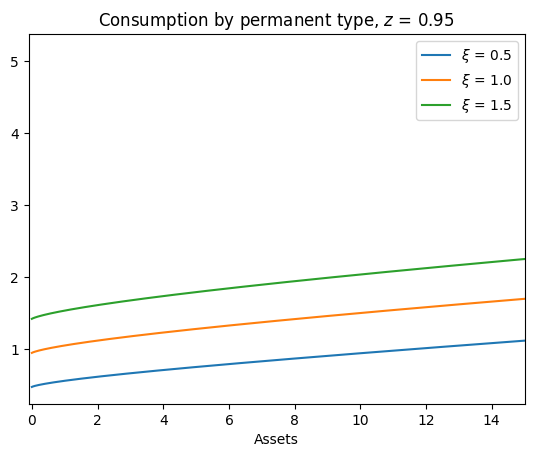

In [23]:
c_fix,a_fix,vbeg_a_fix,it = solve_hh_ss_fix(par,xi_grid,par.r,par.w)
print(f'converged in {it} iterations')

i_z = par.Nz//2
for i_fix in range(xi_grid.size):
    plt.plot(par.a_grid,c_fix[i_fix,i_z],label=f'$\\xi$ = {xi_grid[i_fix]}')
plt.xlim(-0.1,15)
plt.title(f'Consumption by permanent type, $z$ = {par.z_grid[i_z]:.2f}')
plt.xlabel('Assets')
plt.legend()
plt.show()

The three functions look like scaled copies of each other, and they are.
Check with the type $\xi = 1.5$: its consumption at $a_{-1}$ should be $1.5$ times the consumption of the $\xi = 1$ type at $a_{-1}/1.5$.

In [24]:
c_scaled = np.zeros((par.Nz,par.Na))
for i_z in range(par.Nz):
    interp_1d_vec(par.a_grid,c_fix[1,i_z],par.a_grid/xi_grid[2],c_scaled[i_z])
c_scaled *= xi_grid[2]

print(f'max relative difference: {np.max(np.abs(c_fix[2]/c_scaled-1)):.2e}')

max relative difference: 1.28e-03
